In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
N = 100
p = 98
gen = 10000

p1 = np.array([])
p2 = np.array([])
p3 = np.array([])
p4 = np.array([])

p1_true = 0
p2_true = 0
p3_true = 0
p4_true = 0

In [ ]:
for i in range(gen):
    doors = np.zeros(N , dtype=bool)
    
    car = np.random.randint(0 , N)
    removed_door = -1
    doors[car] = True
    doors_index = np.arange(len(doors))
    
    st_choice = np.random.randint(0 , N)

    doors_index_edit = np.delete( doors_index , np.where(doors_index == car))
    doors_index_edit = np.delete( doors_index_edit , np.where(doors_index_edit == st_choice))
    th_option_sample = np.copy( doors_index )
    
    th_choice = st_choice
    open_door_vec = np.random.choice( doors_index_edit , size = p , replace= False)
    nd_choice_sample = np.copy(doors_index)
    unavailable_doors = np.array([car , th_choice])
    
    for i in range(p):
        # genero available doors e unavailable doors
        available_doors = doors_index
        for i in unavailable_doors:
            available_doors = np.delete( available_doors , np.where(available_doors == unavailable_doors[i]))
        unavailable_doors = np.delete( unavailable_doors , np.where(unavailable_doors == th_choice))

        # aggiungo una nuova porta a unavaiable doors
        while removed_door in unavailable_doors:
            removed_door = np.random.choice( doors_index )
        unavailable_doors = np.append( unavailable_doors , removed_door)
        th_choice = np.random.choice( th_option_sample )
        th_option_sample = np.delete( th_option_sample , np.where(th_option_sample == open_door_vec[i]))
        

    for door in open_door_vec:
        nd_choice_sample = np.delete(nd_choice_sample , np.where(door == nd_choice_sample))
    
    
    newcomer_choice = np.random.choice( nd_choice_sample) 
    nd_choice_sample = np.delete(nd_choice_sample , np.where(nd_choice_sample == st_choice))
    # print(nd_choice_sample , open_door_vec)
    nd_choice = np.random.choice( nd_choice_sample)
    p1 = np.append(p1, doors[st_choice])
    p2 = np.append(p2, doors[nd_choice])
    choice = np.random.rand()
    p3 = np.append(p3 , doors[newcomer_choice])

    if p1[-1]: p1_true+=1
    if p2[-1]: p2_true+=1
    if p3[-1]: p3_true+=1

    if i % 100 == 0:
        progress = i / gen
        bar_length = 50
        filled = int(bar_length * progress)
        bar = '█' * filled + '░' * (bar_length - filled)
        print(f'\rProgress: [{bar}] {i}/{gen} ({100*progress:.1f}%)\t {p1_true}  {p2_true}   {p3_true}', end='', flush=True)



KeyboardInterrupt: 

0.0093 0.9907 0.4914


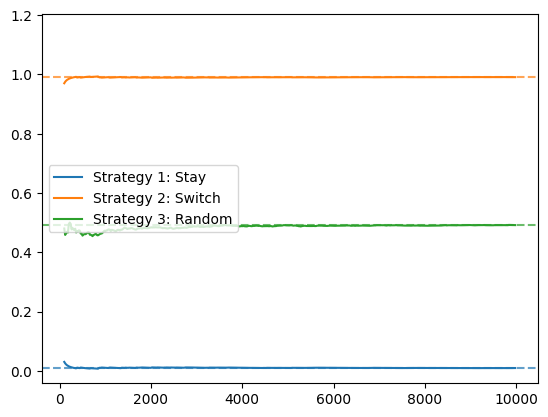

In [ ]:
p1 = np.array( p1 , dtype= int)
p2 = np.array( p2 , dtype= int)
p3 = np.array( p3 , dtype= int)

# plt.hist(p1, density=True, alpha=0.4, label='Strategy 1: Stay')
# plt.hist(p2, density=True, alpha=0.4, label='Strategy 2: Switch')
# plt.hist(p3, density=True, alpha=0.4, label='Strategy 3: Random')
# plt.legend()
# plt.show()

arr1 = []
arr2 = []
arr3 = []

x_vals = range(100, gen, 20)

for i in x_vals:
    count_1 = np.count_nonzero(p1[:i:] == True) 
    count_2 = np.count_nonzero(p2[:i:] == True) 
    count_3 = np.count_nonzero(p3[:i:] == True) 
    arr1.append(count_1/i)
    arr2.append(count_2/i)
    arr3.append(count_3/i)



plt.plot(x_vals, arr1, label='Strategy 1: Stay')
plt.plot(x_vals, arr2, label='Strategy 2: Switch')
plt.plot(x_vals, arr3, label='Strategy 3: Random')
plt.axhline(y=p1_true/gen, color='C0', linestyle='--', alpha=0.7)
plt.axhline(y=p2_true/gen, color='C1', linestyle='--', alpha=0.7)
plt.axhline(y=p3_true/gen, color='C2', linestyle='--', alpha=0.7)

print(p1_true/gen , p2_true/gen, p3_true/gen)

# add extra space at the top of the plot
ymin, ymax = plt.ylim()
plt.ylim(ymin, ymax + 0.15 * (ymax - ymin))

legend_loc = 'best'  # change this (e.g. 'best', 'lower left', 'center')
plt.legend(loc=legend_loc)
# plt.show()

